# TFM — Sistema de Apoyo a la Clasificación
## 01: Entendimiento de Datos Orientado a Negocio (Data Understanding)
---

### Contexto del Proyecto
El **Programa BÁSICO** entrega tarjetas monedero a familias vulnerables para adquirir artículos de primera necesidad. El gran reto operativo consiste en auditar el **Fichero 03** (los tickets del supermercado) y certificar si los fondos públicos han financiado artículos `PERMITIDOS` o `NO PERMITIDOS`, de acuerdo a las directrices europeas.

### Objetivo de este Notebook
Este documento presenta el análisis inicial del ecosistema de datos extraído directamente de la operativa diaria. No solo mediremos filas y columnas, sino que demostraremos las **asimetrías, ruidos y realidades** que justifican científicamente nuestra arquitectura de Inteligencia Artificial.

> **Nota:** Este notebook se centra en el **relato de negocio**. El análisis técnico-estadístico detallado (nulos, correlaciones, distribuciones numéricas) se encuentra en el notebook complementario `01b_data_understanding_technical.ipynb`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

COLOR_P = '#2ECC71'  # Verde Permitido
COLOR_NP = '#E74C3C' # Rojo No Permitido

# === CARGA DEL DATASET ===
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/TFM - Master en IA y Ciencia de Datos/data/raw'
try:
    df = pd.read_csv(
        f'{DATA_PATH}/Dataset.csv',
        sep=';',
        dtype={'COD_EAN': str, 'ID_TARJETA': str},
        low_memory=False
    )
    df['ESTADO'] = df['ESTADO'].astype(str).str.strip().str.upper()
    print(f'\u2705 Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
except FileNotFoundError:
    raise FileNotFoundError('\u26A0\uFE0F Sube el fichero Dataset.csv al entorno de Google Colab.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset cargado: 659,272 filas x 18 columnas


## 1. El Volumen de Datos y el Problema de la Memoria
La primera dimensión crítica de cualquier proyecto moderno de ciencia de datos es validar la viabilidad técnica.

In [ ]:
filas, columnas = df.shape
print(f'\U0001F539 Total de Artículos Individuales: {filas:,}')
print(f'\U0001F539 Variables extraídas por ticket: {columnas}')
print(f'\U0001F539 Tamaño estimado en Memoria RAM: {df.memory_usage(deep=True).sum() / 1e6:.1f} Megabytes')
display(df[['NOMBRE_EMPRESA', 'DESCRIPCION_ARTICULO', 'FAMILIA', 'ESTADO']].head())

🔹 Total de Artículos Individuales: 659,272
🔹 Variables extraídas por ticket: 18
🔹 Tamaño estimado en Memoria RAM: 576.0 Megabytes


,NOMBRE_EMPRESA,DESCRIPCION_ARTICULO,FAMILIA,ESTADO
0,SUPERMERCADO1,YOGUR LIQUIDO 0% 0% CON FRESA,Yogures,PERMITIDO
1,SUPERMERCADO1,ARANDANOS,Fresón/Berries,PERMITIDO
2,SUPERMERCADO1,PAÑAL T-5 (13-18KG),Pañales desechables,PERMITIDO
3,SUPERMERCADO1,ATUN EN ACEITE DE OLIVA,Conservas de pescado/marisco,PERMITIDO
4,SUPERMERCADO1,ACEITE DE OLIVA VIRGEN EXTRA,Aceites,PERMITIDO


> 🎯 **Conclusión de Negocio:** Tenemos casi 650.000 filas. Un volumen tan agresivo descarta el uso indiscriminado de Inteligencias Artificiales Genéricas (LLMs en la nube o local) dado que rebasaríamos los límites computacionales comerciales (RAM y tokens). Justifica empíricamente que usemos un sistema híbrido frugal y destilado en máquina local (Colab).

## 2. El Desbalance Extremo: Más allá de la Simple "Exactitud" (Accuracy)
En problemas de fraude o auditoría, la verdad nunca es simétrica, la inmensa mayoría de las transacciones son lícitas.

| ESTADO       |   count |
|:-------------|--------:|
| PERMITIDO    |  656654 |
| NO PERMITIDO |    2618 |


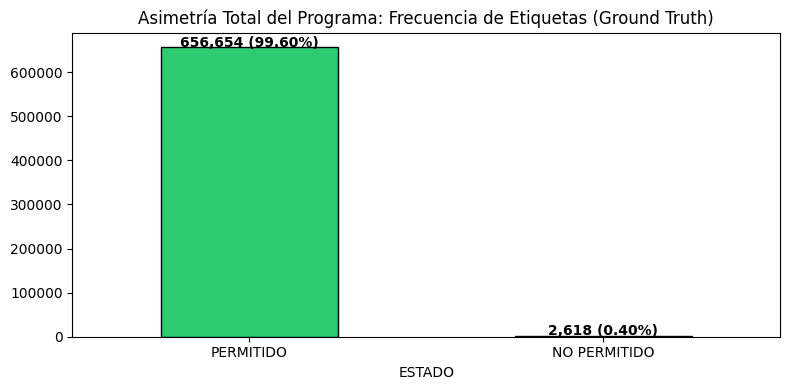


Ratio de desbalance: 251:1


In [ ]:
target_counts = df['ESTADO'].value_counts()
target_pct = df['ESTADO'].value_counts(normalize=True) * 100

print(target_counts.reset_index().to_markdown(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
target_counts.plot(kind='bar', color=[COLOR_P, COLOR_NP], edgecolor='black', ax=ax)
ax.set_title('Asimetría Total del Programa: Frecuencia de Etiquetas (Ground Truth)')
for i, v in enumerate(target_counts):
    ax.text(i, v + 1000, f'{v:,} ({target_pct.iloc[i]:.2f}%)', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ratio = target_counts.max() / target_counts.min()
print(f'\nRatio de desbalance: {ratio:.0f}:1')

> 🎯 **Conclusión de Negocio:** Detectamos un espectacular desbalance **(ratio ~ 270:1)**. La inmensa mayoría de familias compran artículos legales (99.6%). Esto significa que si programamos un robot ciego que por defecto grite "PERMITIDO" en todas las validaciones, alcanzará un 99.6% de Exactitud (Accuracy) matemática, pero **fallará en capturar el 100% del fraude (error de negocio)**.
>
> **Impacto TFM:** Queda descartada el Accuracy como métrica. El éxito de nuestro sistema debe medirse prioritariamente por la capacidad para detectar a la aguja en el pajar matemático (Métricas Recall y F1-Macro), y deberá obligar al coste del algoritmo final a ser ultra punitivo contra errores tipificados como "falsos positivos" sobre productos ilegales.

## 3. Asimetría Semántica: El Riesgo de los Supermercados
No operamos con una Base de Datos ordenada. Cada supermercado nombra a sus artículos y familias como le conviene. Esta libertad es lo que obliga al FSE+ a depender del trabajo manual de los validadores.

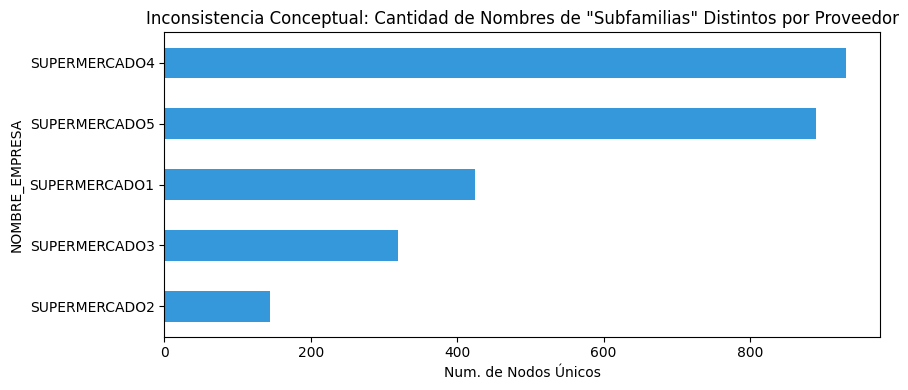


Ejemplo de Subfamilias que provocan Bloqueo Directo (Reglas Duras):
| SUBFAMILIA                 |   count |
|:---------------------------|--------:|
| PIZZAS REFRIGERADAS        |     550 |
| OTROS POSTRES              |     278 |
| PIZZAS MASA FINA CONGELADA |     118 |
| BEBIDA FRESCA CAFE OTROS   |     114 |
| ELIXIRES BUCALES           |      91 |


In [ ]:
# Veamos cuantas subfamilias únicas tiene cada supermercado
empresa_tax = df.groupby('NOMBRE_EMPRESA')['SUBFAMILIA'].nunique().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
empresa_tax.plot(kind='barh', color='#3498DB', ax=ax)
ax.set_title('Inconsistencia Conceptual: Cantidad de Nombres de "Subfamilias" Distintos por Proveedor')
ax.set_xlabel('Num. de Nodos Únicos')
plt.tight_layout()
plt.show()

print('\nEjemplo de Subfamilias que provocan Bloqueo Directo (Reglas Duras):')
np_only = df[df['ESTADO'] == 'NO PERMITIDO']['SUBFAMILIA'].value_counts().head(5)
print(np_only.to_markdown())

> 🎯 **Conclusión de Negocio:** Nuestro Análisis confirma empíricamente que existe una "Torre de Babel" descriptiva. Existen cientos de categorizaciones diferentes entre los 5 supermercados participantes.
>
> **Impacto TFM:** Esta asimetría taxonómica justifica que el modelo de IA se entrene exclusivamente sobre el **texto de la descripción del artículo** (`DESCRIPCION_ARTICULO`), ya que es la única variable semánticamente comparable entre proveedores. Las taxonomías internas (FAMILIA, SUBFAMILIA) se explotarán únicamente en la **Fase 1 determinista** (Listas Negras por subfamilia) como reglas de bloqueo previas al clasificador NLP.

## 4. El Ruido Textual

In [ ]:
df['len_chars'] = df['DESCRIPCION_ARTICULO'].astype(str).str.len()
cortos = df[df['len_chars'] < 10]['DESCRIPCION_ARTICULO'].nunique()
ruido = df['DESCRIPCION_ARTICULO'].astype(str).str.contains(r'[./\-]', regex=True).mean() * 100

print(f'\U0001F539 Descripciones extremadamente ambiguas (<10 caracteres): {cortos:,} productos distintos')
print(f'\U0001F539 Impacto del ruido y Abreviaturas logísticas (con puntos/barras): {ruido:.1f}% de las filas')

print('\nEjemplo del desafío de Abreviaturas Operativas (Truncamientos):')
display(df['DESCRIPCION_ARTICULO'].dropna().sample(5, random_state=42))

🔹 Descripciones extremadamente ambiguas (<10 caracteres): 84 productos distintos
🔹 Impacto del ruido y Abreviaturas logísticas (con puntos/barras): 31.4% de las filas

Ejemplo del desafío de Abreviaturas Operativas (Truncamientos):


,DESCRIPCION_ARTICULO
502949,PANES 5 UNIDADES CRF
424955,PIMIENTO ROJO (MERCADO)
617392,PECHUGA POLLO FINAS LONCHAS AUCHAN 150G
168503,LEVADURA ROYAL 6 SOBRES 96 G
457665,S AHUMA 2X180G CRF


> 🎯 **Conclusión de Negocio:** Validar facturas se asemeja a "descifrar el Enigma". Un producto vital subvencionado puede llamarse "LCH DESN T" en un lado y un gasto prohibido "DET. L.P. RP" en otro. El problema humano y manual de las oficinas operativas reside estrictamente aquí.
>
> **Impacto TFM:** Los truncamientos impiden el procesamiento de lenguaje natural clásico (basado solo en diccionarios completos). Se aprueba definitivamente la inclusión operativa de herramientas como **FastText (caracteres N-gram)** en la fase de extracción dispersa (Sparse), mitigando las Abreviaciones fuera de vocabulario (OOV).

## 5. Decisiones Contradictorias y Delegación (Prueba Empírica del Human-In-The-Loop)

In [ ]:
# Detección de conflictos POR SUPERMERCADO
# (la misma descripción en supermercados distintos puede ser un producto diferente)
conflictos_check = df.groupby(['NOMBRE_EMPRESA', 'DESCRIPCION_ARTICULO'])['ESTADO'].nunique()
n_conflictos = (conflictos_check > 1).sum()

print(f'\u26A0\uFE0F Alerta de Calidad: Se han hallado {n_conflictos:,} pares (Empresa + Descripción)')
print('que históricamente los analistas han catalogado tanto de PERMITIDO como de NO PERMITIDO.\n')
print('Ejemplos críticos de la ambigüedad moral/operativa del humano:')

if n_conflictos > 0:
    conflict_pairs = conflictos_check[conflictos_check > 1].index[:3]
    mask = df.apply(lambda r: (r['NOMBRE_EMPRESA'], r['DESCRIPCION_ARTICULO']) in conflict_pairs, axis=1)
    display(df[mask][['NOMBRE_EMPRESA', 'DESCRIPCION_ARTICULO', 'ESTADO']].drop_duplicates().head(6))

⚠️ Alerta de Calidad: Se han hallado 34 pares (Empresa + Descripción)
que históricamente los analistas han catalogado tanto de PERMITIDO como de NO PERMITIDO.

Ejemplos críticos de la ambigüedad moral/operativa del humano:


,NOMBRE_EMPRESA,DESCRIPCION_ARTICULO,ESTADO
4895,SUPERMERCADO1,GEL DE HIGIENE INTIMA,PERMITIDO
10490,SUPERMERCADO1,SALSA BRAVA,PERMITIDO
16745,SUPERMERCADO1,SALSA BRAVA,NO PERMITIDO
24833,SUPERMERCADO1,GEL DE HIGIENE INTIMA,NO PERMITIDO
61030,SUPERMERCADO4,BAGELS CLASICO NEW YORK B.300G,NO PERMITIDO
85046,SUPERMERCADO4,BAGELS CLASICO NEW YORK B.300G,PERMITIDO


> 🎯 **Conclusión de Negocio Final:** Los propios dictaminadores humanos dudan o yerran en la catalogación operativa.
>
> **Impacto TFM:** Esto es prueba irrefutable de que la Inteligencia Artificial dictaminadora nunca debe actuar como "Juez Definitivo 100% Autónomo". Es estrictamente necesario implementar las **barreras estocásticas de incertidumbre probabilística (0.75 - 0.95)** explicadas en la arquitectura. Toda transacción gris, y toda colisión sintáctica histórica, será segregada de forma forzosa bajo la categoría **REVISAR**.

---
**Siguiente Fase:** *Preprocesamiento, Depuración de Nulos y Transformación Léxica de la Matriz Generadora* (Data Preparation).

**Análisis complementario:** Para el detalle técnico-estadístico (nulos, correlaciones, distribuciones numéricas, cobertura EAN), consultar `01b_data_understanding_technical.ipynb`.